In [4]:
# 필요한 라이브러리를 불러온다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 주피터 노트북에서 그래프를 바로 출력하기 위한 설정이다.
%matplotlib inline

# 타이타닉 학습용 데이터를 csv 파일에서 불러온다.
titanic_df = pd.read_csv('./titanic_train.csv')

# 상위 3개의 데이터를 확인한다.
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
# 데이터의 전체적인 구조와 결측치 여부를 확인한다.
print('\n ### train 데이터 정보 ###  \n')
print(titanic_df.info())


 ### train 데이터 정보 ###  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [6]:
# Age 컬럼의 결측치는 평균값으로 대체한다.
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)

# Cabin 컬럼의 결측치는 'N'으로 대체한다.
titanic_df['Cabin'].fillna('N', inplace=True)

# Embarked 컬럼의 결측치는 'N'으로 대체한다.
titanic_df['Embarked'].fillna('N', inplace=True)

# 전체 데이터셋의 결측치 개수를 출력한다.
print('데이터 세트 Null 값 갯수 ', titanic_df.isnull().sum().sum())

데이터 세트 Null 값 갯수  0


/tmp/ipykernel_737/3952757887.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
/tmp/ipykernel_737/3952757887.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [7]:
# Sex, Cabin, Embarked 컬럼의 값 분포를 확인한다.
print(' Sex 값 분포 :\n', titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n', titanic_df['Embarked'].value_counts())

 Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [8]:
# Cabin 값에서 첫 글자만 추출하여 객실 등급 문자만 남긴다.
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]

# 변환된 Cabin 값의 상위 3개를 확인한다.
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [9]:
# 성별과 생존 여부별 인원 수를 그룹화하여 확인한다.
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

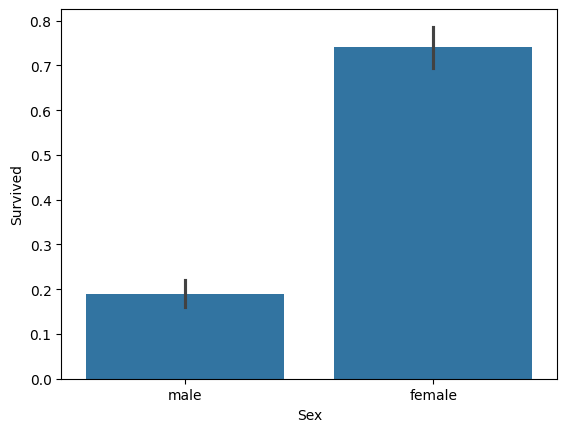

In [10]:
# 성별에 따른 평균 생존율을 막대그래프로 시각화한다.
sns.barplot(x='Sex', y='Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

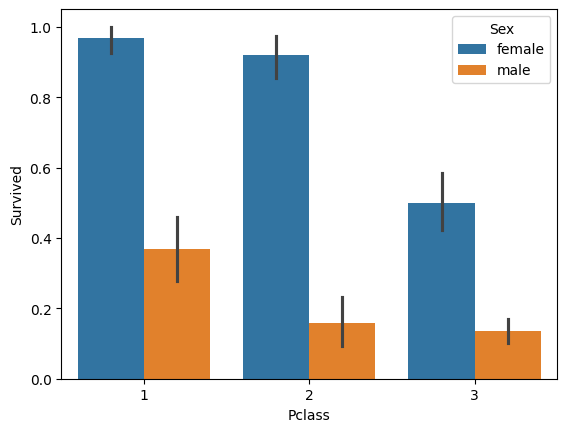

In [11]:
# 객실 등급(Pclass)과 성별(Sex)에 따른 생존율을 막대그래프로 시각화한다.
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

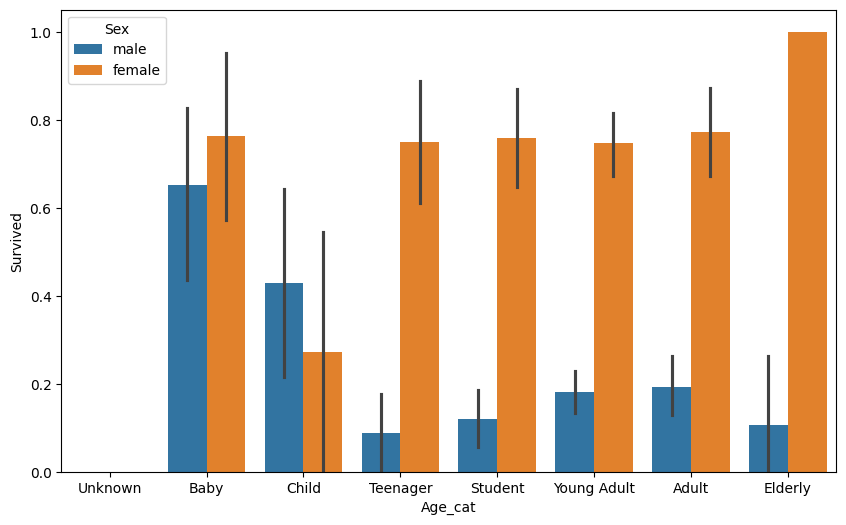

In [12]:
# 나이를 입력받아 연령대 범주를 반환하는 함수를 정의한다.
def get_category(age):
    cat = ''
    if age <= -1:
        cat = 'Unknown'
    elif age <= 5:
        cat = 'Baby'
    elif age <= 12:
        cat = 'Child'
    elif age <= 18:
        cat = 'Teenager'
    elif age <= 25:
        cat = 'Student'
    elif age <= 35:
        cat = 'Young Adult'
    elif age <= 60:
        cat = 'Adult'
    else:
        cat = 'Elderly'

    return cat

# 그래프 크기를 크게 설정한다.
plt.figure(figsize=(10, 6))

# X축에 표시할 연령대 순서를 지정한다.
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# Age 컬럼의 값을 연령대 범주로 변환하여 Age_cat 컬럼을 생성한다.
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x: get_category(x))

# 연령대와 성별에 따른 생존율을 막대그래프로 시각화한다.
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)

# 시각화 후 임시로 만든 Age_cat 컬럼을 삭제한다.
titanic_df.drop('Age_cat', axis=1, inplace=True)

In [13]:
# 전처리 모듈을 불러온다.
from sklearn import preprocessing

# 범주형 컬럼을 Label Encoding하는 함수를 정의한다.
def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = preprocessing.LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])

    return dataDF

# 타이타닉 데이터에 대해 인코딩을 수행한다.
titanic_df = encode_features(titanic_df)

# 인코딩된 결과를 확인한다.
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [14]:
# LabelEncoder를 불러온다.
from sklearn.preprocessing import LabelEncoder

# 결측치를 처리하는 함수를 정의한다.
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 모델에 불필요한 피처를 제거하는 함수를 정의한다.
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 범주형 피처를 가공하고 Label Encoding하는 함수를 정의한다.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 정의한 전처리 함수를 순서대로 적용하는 통합 함수를 정의한다.
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [15]:
# 원본 타이타닉 데이터를 다시 불러온다.
titanic_df = pd.read_csv('./titanic_train.csv')

# 생존 여부(Survived)를 레이블 데이터로 저장한다.
y_titanic_df = titanic_df['Survived']

# Survived 컬럼을 제외한 나머지를 피처 데이터로 저장한다.
X_titanic_df = titanic_df.drop('Survived', axis=1)

# 피처 데이터에 대해 전처리를 수행한다.
X_titanic_df = transform_features(X_titanic_df)

/tmp/ipykernel_737/340051843.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_737/340051843.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [16]:
# train_test_split 함수를 불러온다.
from sklearn.model_selection import train_test_split

# 전체 데이터를 학습용과 테스트용으로 분리한다.
# test_size=0.2는 20%를 테스트용으로 사용한다는 뜻이다.
# random_state=11은 실행할 때마다 같은 결과가 나오도록 고정하는 값이다.
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df, test_size=0.2, random_state=11
)

In [17]:
# 필요한 분류 모델과 정확도 평가 함수를 불러온다.
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 결정트리, 랜덤포레스트, 로지스틱 회귀 모델 객체를 생성한다.
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

# DecisionTreeClassifier 모델을 학습하고 예측 정확도를 출력한다.
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 모델을 학습하고 예측 정확도를 출력한다.
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

# LogisticRegression 모델을 학습하고 예측 정확도를 출력한다.
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659


In [18]:
# KFold를 불러온다.
from sklearn.model_selection import KFold

# KFold 교차 검증을 수행하는 함수를 정의한다.
def exec_kfold(clf, folds=5):
    # 지정한 개수만큼 폴드를 나누는 KFold 객체를 생성한다.
    kfold = KFold(n_splits=folds)

    # 각 교차 검증의 정확도를 저장할 리스트를 생성한다.
    scores = []

    # KFold 교차 검증을 수행한다.
    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        # 각 폴드별 학습용 데이터와 검증용 데이터를 나눈다.
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]

        # 모델을 학습하고 예측을 수행한다.
        clf.fit(X_train, y_train)
        predictions = clf.predict(X_test)

        # 정확도를 계산하여 저장한다.
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)

        # 각 교차 검증별 정확도를 출력한다.
        print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

    # 전체 폴드의 평균 정확도를 계산하여 출력한다.
    mean_score = np.mean(scores)
    print("평균 정확도: {0:.4f}".format(mean_score))

# 결정트리 모델에 대해 KFold 교차 검증을 수행한다.
exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


In [19]:
# GridSearchCV를 불러온다.
from sklearn.model_selection import GridSearchCV

# 탐색할 하이퍼파라미터 값을 딕셔너리 형태로 설정한다.
parameters = {
    'max_depth': [2, 3, 5, 10],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 5, 8]
}

# GridSearchCV 객체를 생성한다.
# 정확도를 기준으로 5-fold 교차 검증을 수행한다.
grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)

# 학습 데이터로 하이퍼파라미터 탐색을 수행한다.
grid_dclf.fit(X_train, y_train)

# 최적 하이퍼파라미터와 최고 정확도를 출력한다.
print('GridSearchCV 최적 하이퍼 파라미터 :', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))

# 가장 좋은 하이퍼파라미터로 학습된 모델을 가져온다.
best_dclf = grid_dclf.best_estimator_

# 최적 모델로 테스트 데이터 예측을 수행한다.
dpredictions = best_dclf.predict(X_test)

# 테스트 데이터 정확도를 계산하여 출력한다.
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715
